<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Spoofed_Traffic_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 

In [1]:
pip show sionna


Name: sionna
Version: 2.0.1
Summary: Sionna - A hardware-accelerated differentiable open-source library for research on communication systems
Home-page: 
Author: 
Author-email: The Sionna contributors <sionna@nvidia.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: h5py, importlib-resources, matplotlib, numpy, scipy, sionna-rt, torch
Required-by: 


In [2]:
import tensorflow as tf
import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation area (meters)
AREA_X = 1000
AREA_Y = 1000

print("Simulation Area:", AREA_X, "x", AREA_Y, "meters")

Simulation Area: 1000 x 1000 meters


In [4]:
bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

print(bs_positions)

[[250 250]
 [750 250]
 [500 750]]


In [5]:
num_users = 30

user_positions = np.random.rand(num_users,2)

user_positions[:,0] *= AREA_X
user_positions[:,1] *= AREA_Y

print(user_positions)

[[4.78912547e+02 6.82964156e+02]
 [1.69901016e+02 5.45390128e+02]
 [3.23912441e+02 2.13748855e+02]
 [5.23527737e+02 1.64208733e+02]
 [1.05070984e+02 4.47413021e+02]
 [4.13101010e+02 9.68310344e+02]
 [2.35402223e+02 3.46691765e+02]
 [4.81579675e+02 6.88256018e+02]
 [8.88973497e+02 2.38294527e+02]
 [1.78090243e+02 3.69427415e-04]
 [4.81267392e+02 8.72092638e+02]
 [2.23422206e+02 5.93054467e+02]
 [3.31830511e+02 2.08574825e+02]
 [3.40806029e+02 1.88685195e+02]
 [6.69821574e+01 4.10358123e+02]
 [3.22060978e+02 8.27966835e+01]
 [6.49299702e+02 3.08339440e+02]
 [7.37004839e+02 8.94680118e+02]
 [6.67548793e+02 7.64998805e+02]
 [2.49796773e+02 3.98681042e+01]
 [8.39495700e+02 3.47954903e+02]
 [2.02141828e+02 7.74800656e+02]
 [8.19037688e+02 5.70879450e+02]
 [6.21897592e+02 9.83425526e+02]
 [2.07361858e+02 1.70154538e+02]
 [8.90818110e+02 3.00002424e+02]
 [5.30651092e+02 3.68053030e+02]
 [2.74581104e+02 7.67512716e+02]
 [7.40839518e+02 2.72628006e+02]
 [5.11440268e+02 4.41692047e+02]]


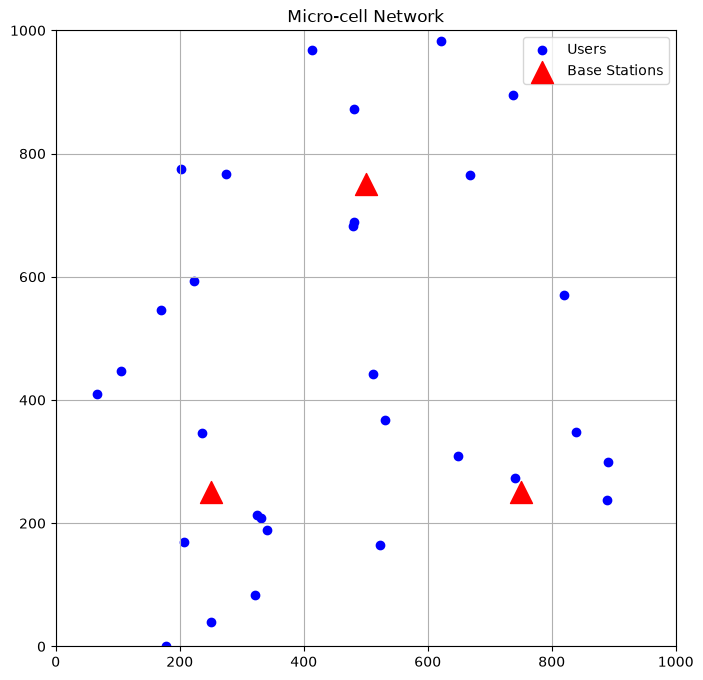

In [6]:
plt.figure(figsize=(8,8))

# Users
plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c='blue',
    label='Users'
)

# Base Stations
plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    c='red',
    s=250,
    marker='^',
    label='Base Stations'
)

plt.xlim(0,AREA_X)
plt.ylim(0,AREA_Y)

plt.grid(True)
plt.legend()

plt.title("Micro-cell Network")

plt.savefig("figures_network_layout_1.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
import tensorflow as tf
import sionna
import numpy as np
import matplotlib.pyplot as plt


# Distance matrix
distance_matrix = np.zeros((len(user_positions), len(bs_positions)))

for i, user in enumerate(user_positions):

    for j, bs in enumerate(bs_positions):

        distance = np.linalg.norm(user-bs)

        distance_matrix[i,j] = distance

print(distance_matrix)

[[489.75393277 510.8290982   70.2743555 ]
 [306.05747051 650.9763124  388.36907548]
 [ 82.32371748 427.62688554 564.42193309]
 [286.66629457 242.17726453 586.26356123]
 [244.9006343  674.46670539 497.52166519]
 [736.59465764 793.39188274 234.96987193]
 [ 97.78748614 523.60306498 482.35828637]
 [495.67881035 513.92393221  64.43312585]
 [639.08070565 139.46559089 642.76190969]
 [260.13617297 624.16390943 816.16501869]
 [663.68957914 677.6551228  123.52134623]
 [344.08247013 628.46681698 318.00499437]
 [ 91.71846932 420.21633356 566.94108827]
 [109.56842671 413.76226437 583.45268062]
 [243.3315812  701.58969562 550.32813523]
 [182.07068301 459.44396347 690.5233965 ]
 [403.53902178 116.37886537 466.21288197]
 [807.95183513 644.81107992 277.67540458]
 [663.00132957 521.5572552  168.21879215]
 [210.13199412 542.54832236 752.92029084]
 [597.57873402 132.68249096 526.21059471]
 [526.97830401 758.65954509 298.8888814 ]
 [653.27445366 328.22221708 365.8814259 ]
 [822.32646893 744.52886398 263.33

In [8]:
assignments = np.argmin(distance_matrix, axis=1)

print(assignments)

[2 0 0 1 0 2 0 2 1 0 2 2 0 0 0 0 1 2 2 0 1 2 1 2 0 1 1 2 1 1]


In [9]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments==bs)

    print(f"BS {bs+1} has {count} users")

BS 1 has 11 users
BS 2 has 9 users
BS 3 has 10 users


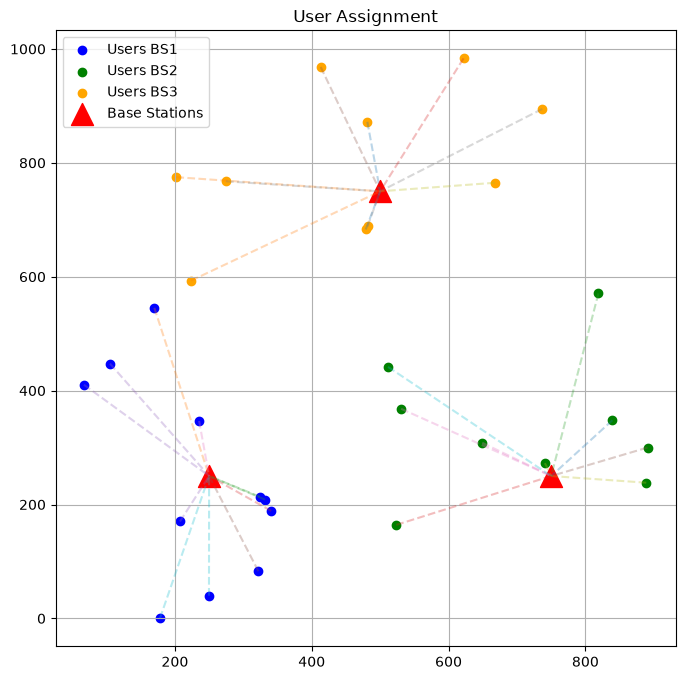

In [10]:
plt.figure(figsize=(8,8))

colors=['blue','green','orange']

# Draw users

for bs in range(3):

    idx = assignments==bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users BS{bs+1}'
    )

# Draw Base Stations

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=250,
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs=assignments[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3
    )

plt.grid()

plt.legend()

plt.title("User Assignment")

plt.savefig("figures_network_layout_2.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
import pandas as pd

results = pd.DataFrame({
    "User": range(1, len(assignments)+1),
    "Assigned_BS": assignments
})

results.to_csv("user_assignment.csv", index=False)

In [12]:
# -------------------------------
# Network Parameters
# -------------------------------

frequency = 3500      # MHz (5G frequency)
tx_power = 30         # dBm (micro-cell transmit power)

print("Frequency:", frequency, "MHz")
print("Transmit Power:", tx_power, "dBm")

Frequency: 3500 MHz
Transmit Power: 30 dBm


In [13]:
distance_matrix
print(distance_matrix)

[[489.75393277 510.8290982   70.2743555 ]
 [306.05747051 650.9763124  388.36907548]
 [ 82.32371748 427.62688554 564.42193309]
 [286.66629457 242.17726453 586.26356123]
 [244.9006343  674.46670539 497.52166519]
 [736.59465764 793.39188274 234.96987193]
 [ 97.78748614 523.60306498 482.35828637]
 [495.67881035 513.92393221  64.43312585]
 [639.08070565 139.46559089 642.76190969]
 [260.13617297 624.16390943 816.16501869]
 [663.68957914 677.6551228  123.52134623]
 [344.08247013 628.46681698 318.00499437]
 [ 91.71846932 420.21633356 566.94108827]
 [109.56842671 413.76226437 583.45268062]
 [243.3315812  701.58969562 550.32813523]
 [182.07068301 459.44396347 690.5233965 ]
 [403.53902178 116.37886537 466.21288197]
 [807.95183513 644.81107992 277.67540458]
 [663.00132957 521.5572552  168.21879215]
 [210.13199412 542.54832236 752.92029084]
 [597.57873402 132.68249096 526.21059471]
 [526.97830401 758.65954509 298.8888814 ]
 [653.27445366 328.22221708 365.8814259 ]
 [822.32646893 744.52886398 263.33

In [14]:
distance_km = distance_matrix / 1000

# Avoid log10(0)
distance_km[distance_km < 0.001] = 0.001

import numpy as np

path_loss = 32.44 \
            + 20*np.log10(frequency) \
            + 20*np.log10(distance_km)

print(path_loss)

[[ 97.12091953  97.48687344  80.25729831]
 [ 93.03742058  99.5926646   95.10625371]
 [ 81.63186036  95.94266093  98.35343852]
 [ 92.46889354  91.00402827  98.68321892]
 [ 91.10115909  99.9005712   97.25760083]
 [100.66593218 101.31111594  90.74160449]
 [ 83.12702652  97.70140449  96.98875576]
 [ 97.22536796  97.53933773  79.5035449 ]
 [ 99.43247501  86.21070231  99.48236354]
 [ 91.62537582  99.22733395 101.55692042]
 [ 99.76066086  99.9415354   85.15620121]
 [ 94.05461183  99.28700793  93.3700397 ]
 [ 82.57049685  95.79081947  98.39211955]
 [ 84.1150694   95.65637849  98.64147368]
 [ 91.04533045 100.24302492  98.13379522]
 [ 88.52616132  96.56601188 100.10492885]
 [ 95.43907162  84.63884326  96.69304627]
 [101.46907032  99.51001072  92.19210915]
 [ 99.75164887  97.66740071  87.83885109]
 [ 89.77120453  98.01012939 100.85634091]
 [ 98.84926356  85.77763321  97.74455265]
 [ 97.7572156  100.92229941  92.83155608]
 [ 99.6232744   93.64472038  94.58816815]
 [101.62224628 100.75899167  91.73

In [15]:
received_power = tx_power - path_loss

print(received_power)

[[-67.12091953 -67.48687344 -50.25729831]
 [-63.03742058 -69.5926646  -65.10625371]
 [-51.63186036 -65.94266093 -68.35343852]
 [-62.46889354 -61.00402827 -68.68321892]
 [-61.10115909 -69.9005712  -67.25760083]
 [-70.66593218 -71.31111594 -60.74160449]
 [-53.12702652 -67.70140449 -66.98875576]
 [-67.22536796 -67.53933773 -49.5035449 ]
 [-69.43247501 -56.21070231 -69.48236354]
 [-61.62537582 -69.22733395 -71.55692042]
 [-69.76066086 -69.9415354  -55.15620121]
 [-64.05461183 -69.28700793 -63.3700397 ]
 [-52.57049685 -65.79081947 -68.39211955]
 [-54.1150694  -65.65637849 -68.64147368]
 [-61.04533045 -70.24302492 -68.13379522]
 [-58.52616132 -66.56601188 -70.10492885]
 [-65.43907162 -54.63884326 -66.69304627]
 [-71.46907032 -69.51001072 -62.19210915]
 [-69.75164887 -67.66740071 -57.83885109]
 [-59.77120453 -68.01012939 -70.85634091]
 [-68.84926356 -55.77763321 -67.74455265]
 [-67.7572156  -70.92229941 -62.83155608]
 [-69.6232744  -63.64472038 -64.58816815]
 [-71.62224628 -70.75899167 -61.73

In [16]:
assignments_signal = np.argmax(received_power, axis=1)

print(assignments_signal)


[2 0 0 1 0 2 0 2 1 0 2 2 0 0 0 0 1 2 2 0 1 2 1 2 0 1 1 2 1 1]


In [17]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments_signal == bs)

    print(f"BS {bs+1}: {count} users")

BS 1: 11 users
BS 2: 9 users
BS 3: 10 users


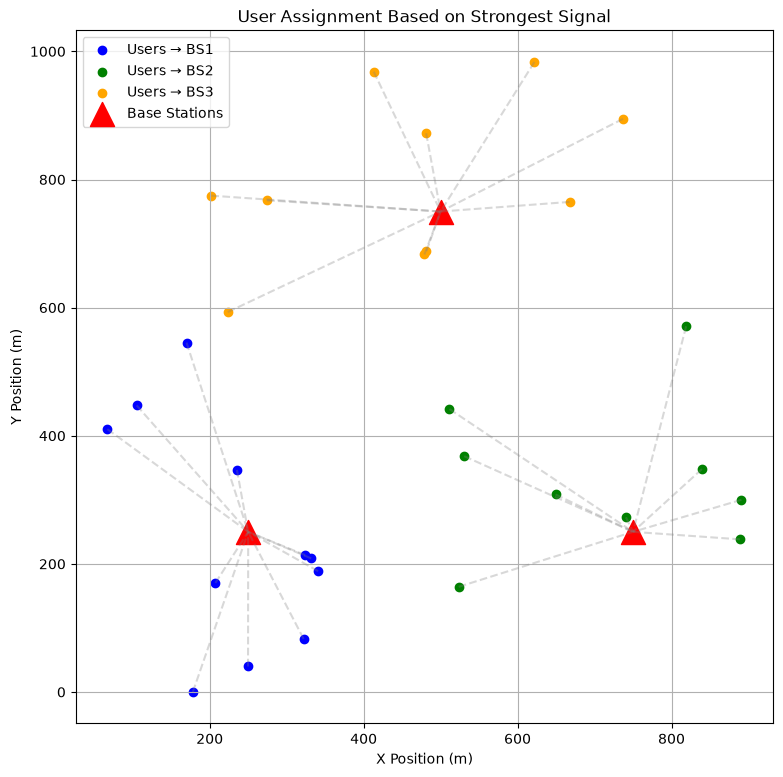

In [18]:
plt.figure(figsize=(9,9))

colors = ['blue','green','orange']

for bs in range(3):

    idx = assignments_signal == bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users → BS{bs+1}'
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    s=300,
    color='red',
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs = assignments_signal[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3,
        color='gray'
    )

plt.title("User Assignment Based on Strongest Signal")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step4_user_assignment_signal.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [19]:
import pandas as pd

results = pd.DataFrame({
    "User": np.arange(1, len(user_positions)+1),
    "Assigned_BS": assignments_signal + 1,
    "Best_RSRP_dBm": np.max(received_power, axis=1)
})

print(results.head())

results.to_csv("step4_user_assignment.csv", index=False)

   User  Assigned_BS  Best_RSRP_dBm
0     1            3     -50.257298
1     2            1     -63.037421
2     3            1     -51.631860
3     4            2     -61.004028
4     5            1     -61.101159


In [20]:
#STEP 5 - SINR Calculation
# Convert dBm to mW

received_power_mW = 10 ** (received_power / 10)

print(received_power_mW)

[[1.94047498e-07 1.78366239e-07 9.42475716e-06]
 [4.96887352e-07 1.09833175e-07 3.08584870e-07]
 [6.86774188e-06 2.54527028e-07 1.46101995e-07]
 [5.66383569e-07 7.93591801e-07 1.35418534e-07]
 [7.76039972e-07 1.02315841e-07 1.88035529e-07]
 [8.57840966e-08 7.39415254e-08 8.43023247e-07]
 [4.86740348e-06 1.69769454e-07 2.00043491e-07]
 [1.89436300e-07 1.76224476e-07 1.12110299e-05]
 [1.13960015e-07 2.39292876e-06 1.12658418e-07]
 [6.87800390e-07 1.19472130e-07 6.98727696e-08]
 [1.05665671e-07 1.01355299e-07 3.05056216e-06]
 [3.93132381e-07 1.17841757e-07 4.60252366e-07]
 [5.53286807e-06 2.63583398e-07 1.44806496e-07]
 [3.87697553e-06 2.71870541e-07 1.36726480e-07]
 [7.86080377e-07 9.45578323e-08 1.53681106e-07]
 [1.40405419e-06 2.20495033e-07 9.76128775e-08]
 [2.85820147e-07 3.43649466e-06 2.14138804e-07]
 [7.13005644e-08 1.11943512e-07 6.03655393e-07]
 [1.05885164e-07 1.71103908e-07 1.64480679e-06]
 [1.05409450e-06 1.58120093e-07 8.21043011e-08]
 [1.30338778e-07 2.64384919e-06 1.680911

In [21]:
# Thermal Noise (Assume a simple fixed thermal noise power)
noise_dBm = -100

noise_mW = 10 ** (noise_dBm / 10)

print("Noise Power (mW):", noise_mW)

Noise Power (mW): 1e-10


In [22]:
# Calculate SINR
sinr = []

for i in range(len(user_positions)):

    serving_bs = assignments_signal[i]

    signal = received_power_mW[i, serving_bs]

    interference = np.sum(received_power_mW[i]) - signal

    sinr_linear = signal / (interference + noise_mW)

    sinr.append(sinr_linear)

sinr = np.array(sinr)

# Convert SINR to dB
sinr_dB = 10 * np.log10(sinr)

print(sinr_dB)

[14.03127876  0.74543754 12.33963166  0.53320629  4.26810661  7.22193148
 11.19197819 14.86448379 10.23442938  5.59979502 11.68155808 -0.45487875
 11.31768998  9.77091588  5.00422134  6.44672896  8.37094469  5.17522201
  7.73495493  6.42081691  9.47248867  3.21398351 -0.24240494  6.4244577
 13.30914587  9.3197819  -0.38266991  5.31546352 23.4159422  -2.7306908 ]


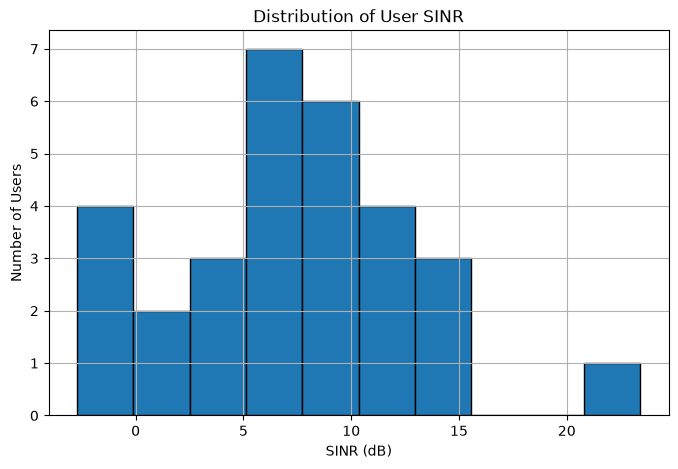

In [23]:
# Plot SINR Distribution
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=10,
         edgecolor='black')

plt.xlabel("SINR (dB)")
plt.ylabel("Number of Users")
plt.title("Distribution of User SINR")

plt.grid(True)

plt.savefig("figures_step5_sinr_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

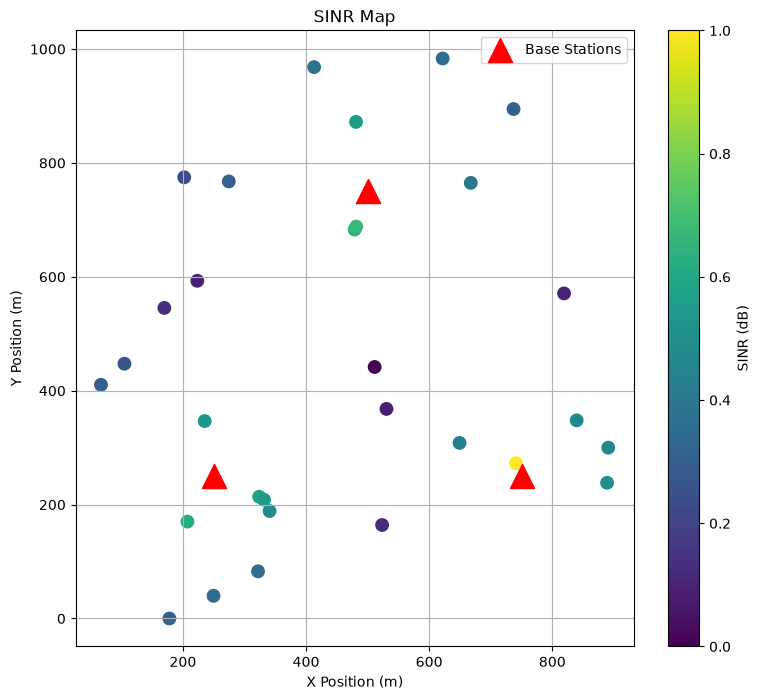

In [24]:
# Network Visualization
plt.figure(figsize=(9,8))

plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c=sinr_dB,
    cmap='viridis',
    s=80
)

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=300,
    label='Base Stations'
)

plt.colorbar(label="SINR (dB)")

plt.title("SINR Map")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step5_sinr_map.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [25]:
# Statistics
print("Average SINR :", np.mean(sinr_dB))

print("Maximum SINR :", np.max(sinr_dB))

print("Minimum SINR :", np.min(sinr_dB))

Average SINR : 7.320465015612204
Maximum SINR : 23.415942198284405
Minimum SINR : -2.730690795855752


In [26]:
# Save Results
results["SINR_dB"] = sinr_dB

results.to_csv(
    "results_step5_sinr_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB
0     1            3     -50.257298  14.031279
1     2            1     -63.037421   0.745438
2     3            1     -51.631860  12.339632
3     4            2     -61.004028   0.533206
4     5            1     -61.101159   4.268107


In [27]:
#====================================================
# STEP 6 - QoS Analysis
#====================================================

# Spectral Efficiency (bits/s/Hz)

spectral_efficiency = np.log2(1 + sinr)

print(spectral_efficiency)


[4.7170144  1.12912097 4.18095298 1.0912803  1.87650371 2.64953359
 3.82357008 4.98419118 3.53039893 2.211202   3.97530075 0.92642374
 3.86242042 3.39041799 2.05843873 2.4362631  2.97676304 2.10180901
 2.79410845 2.42924957 3.30103586 1.63042138 0.96029916 2.43023454
 4.48701627 3.25553665 0.93783957 2.13767663 7.78516294 0.61659302]


In [28]:
# Bandwidth per user

bandwidth = 20e6      # 20 MHz

throughput = bandwidth * spectral_efficiency

throughput_Mbps = throughput / 1e6

print(throughput_Mbps)

[ 94.34028795  22.58241937  83.61905963  21.82560598  37.53007425
  52.99067186  76.47140159  99.68382361  70.60797857  44.22404
  79.50601501  18.52847481  77.2484084   67.80835985  41.16877451
  48.72526206  59.53526084  42.03618012  55.88216898  48.58499139
  66.02071725  32.60842755  19.20598321  48.60469085  89.74032531
  65.11073292  18.75679137  42.75353257 155.70325873  12.33186032]


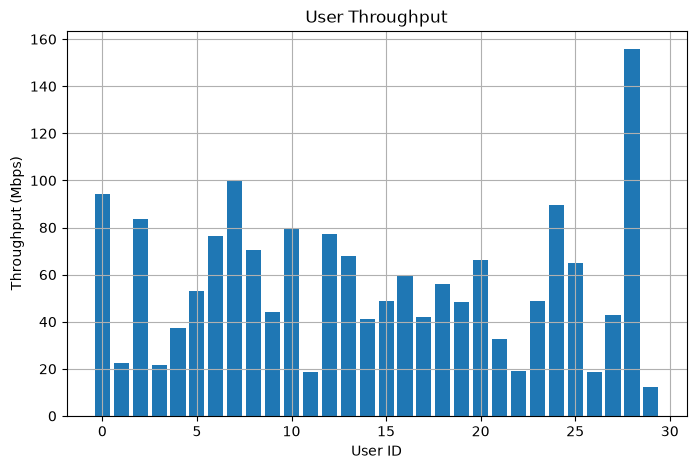

In [29]:
# Plot Throughput

plt.figure(figsize=(8,5))

plt.bar(range(len(throughput_Mbps)),
        throughput_Mbps)

plt.xlabel("User ID")
plt.ylabel("Throughput (Mbps)")
plt.title("User Throughput")

plt.grid(True)

plt.savefig(
    "figures_step6_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Average Throughput
print("Average Throughput:")

print(np.mean(throughput_Mbps),"Mbps")

Average Throughput:
56.45785262857321 Mbps


In [31]:
# Packet Error Rate (PER)
packet_error_rate = np.exp(-sinr)

print(packet_error_rate)

[1.02840346e-11 3.05057710e-01 3.60586355e-08 3.22829705e-01
 6.91248273e-02 5.11977936e-03 1.92951771e-06 4.87893986e-14
 2.60725332e-05 2.65000362e-02 4.01359602e-07 4.06342489e-01
 1.31104274e-06 7.58930870e-05 4.21992476e-02 1.21262848e-02
 1.03621659e-03 3.71618404e-02 2.64252105e-03 1.24487889e-02
 1.42491303e-04 1.22943038e-01 3.88402417e-01 1.24030797e-02
 4.95877594e-10 1.93499093e-04 4.00253414e-01 3.33556543e-02
 4.33812108e-96 5.86695068e-01]


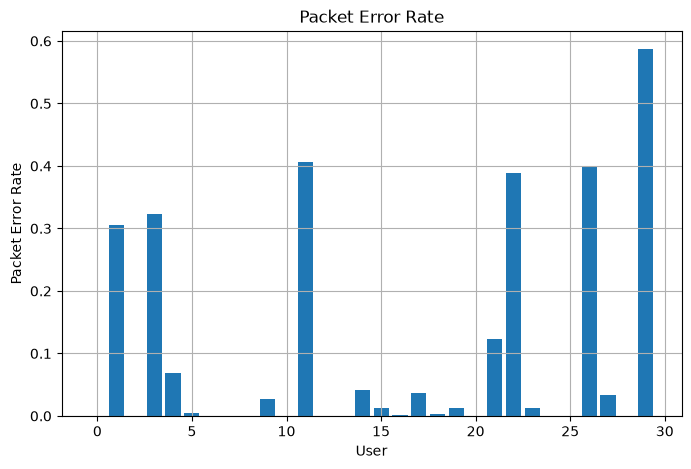

In [32]:
# Plot PER
plt.figure(figsize=(8,5))

plt.bar(range(len(packet_error_rate)),
        packet_error_rate)

plt.xlabel("User")

plt.ylabel("Packet Error Rate")

plt.title("Packet Error Rate")

plt.grid(True)

plt.savefig(
    "figures_step6_packet_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Latency Model
latency = 100/(sinr+1)

print(latency)

[ 3.80221943 45.71942078  5.51325071 46.93446766 27.23429238 15.93715931
  7.06302455  3.15943155  8.65454072 21.59543077  6.35792254 52.61610135
  6.87536245  9.53635668 24.00756975 18.4761606  12.70296304 23.29659469
 14.41748625 18.56619949 10.14586755 32.29938549 51.39503284 18.55352809
  4.45937005 10.47094353 52.20140099 22.72454591  0.45334876 65.22093298]


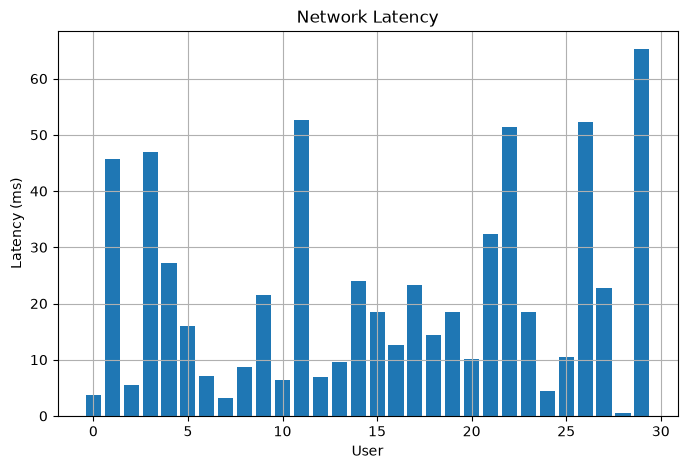

In [34]:
# Plot Latency
plt.figure(figsize=(8,5))

plt.bar(range(len(latency)),
        latency)

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Network Latency")

plt.grid(True)

plt.savefig(
    "figures_step6_latency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# QoS Summary
print("========== QoS SUMMARY ==========")

print("Average SINR:",
      np.mean(sinr_dB),
      "dB")

print("Average Throughput:",
      np.mean(throughput_Mbps),
      "Mbps")

print("Average Latency:",
      np.mean(latency),
      "ms")

print("Average PER:",
      np.mean(packet_error_rate))

========== QoS SUMMARY ==========
Average SINR: 7.320465015612204 dB
Average Throughput: 56.45785262857321 Mbps
Average Latency: 21.346343696800705 ms
Average PER: 0.09290279173751885


In [36]:
# Save Results
results["SINR_dB"] = sinr_dB
results["Spectral_Efficiency"] = spectral_efficiency
results["Throughput_Mbps"] = throughput_Mbps
results["Latency_ms"] = latency
results["PER"] = packet_error_rate

results.to_csv(
    "results_step6_qos_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB  Spectral_Efficiency  \
0     1            3     -50.257298  14.031279             4.717014   
1     2            1     -63.037421   0.745438             1.129121   
2     3            1     -51.631860  12.339632             4.180953   
3     4            2     -61.004028   0.533206             1.091280   
4     5            1     -61.101159   4.268107             1.876504   

   Throughput_Mbps  Latency_ms           PER  
0        94.340288    3.802219  1.028403e-11  
1        22.582419   45.719421  3.050577e-01  
2        83.619060    5.513251  3.605864e-08  
3        21.825606   46.934468  3.228297e-01  
4        37.530074   27.234292  6.912483e-02  


In [37]:
# Step 7
# Save normal network results

normal_throughput = throughput_Mbps.copy()
normal_latency = latency.copy()
normal_per = packet_error_rate.copy()
normal_assignments = assignments_signal.copy()

In [38]:
# Number of users connected to each BS

cell_load = np.zeros(len(bs_positions), dtype=int)

for bs in assignments_signal:
    cell_load[bs] += 1

print("Current Cell Load")

for i, load in enumerate(cell_load):
    print(f"BS{i+1}: {load} users")

Current Cell Load
BS1: 11 users
BS2: 9 users
BS3: 10 users


In [39]:
#----------------------------------------
# Spoofed Traffic Attack
#----------------------------------------

target_bs = 1      # BS2 (index starts from 0)

spoofed_users = 20

print("Attack Target : BS", target_bs+1)
print("Fake Users :", spoofed_users)

Attack Target : BS 2
Fake Users : 20


In [40]:
# Increase Cell Load
attack_cell_load = cell_load.copy()

attack_cell_load[target_bs] += spoofed_users

print("Cell Load After Attack")

for i, load in enumerate(attack_cell_load):
    print(f"BS{i+1}: {load} users")

Cell Load After Attack
BS1: 11 users
BS2: 29 users
BS3: 10 users


In [41]:
# Available Bandwidth Per Cell
total_bandwidth = 20e6      #20 MHz

bandwidth_per_bs = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):
    bandwidth_per_bs[i] = total_bandwidth / attack_cell_load[i]

print(bandwidth_per_bs)

[1818181.81818182  689655.17241379 2000000.        ]


In [42]:
# Calculate New Throughput
attack_throughput = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    attack_bandwidth = bandwidth_per_bs[bs]

    attack_throughput[i] = (
        attack_bandwidth
        * spectral_efficiency[i]
        / 1e6
    )

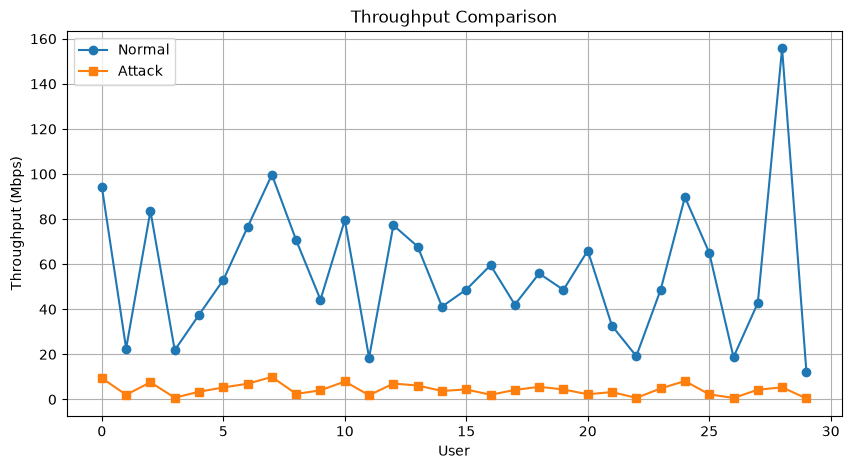

In [43]:
# Plot Throughput Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_throughput,
         marker='o',
         label="Normal")

plt.plot(attack_throughput,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Throughput (Mbps)")

plt.title("Throughput Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_throughput_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# New Latency
attack_latency = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    load_factor = attack_cell_load[bs] / cell_load[bs]

    attack_latency[i] = latency[i] * load_factor

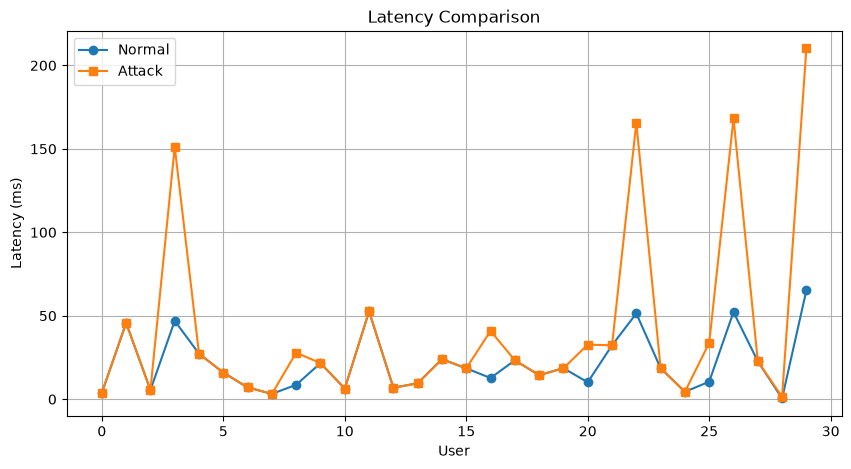

In [45]:
# Plot Latency Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_latency,
         marker='o',
         label="Normal")

plt.plot(attack_latency,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Latency Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# QoS Comparison
print("========== NORMAL ==========")

print("Average Throughput:",
      np.mean(normal_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(normal_latency),
      "ms")

print("\n========== ATTACK ==========")

print("Average Throughput:",
      np.mean(attack_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(attack_latency),
      "ms")

========== NORMAL ==========
Average Throughput: 56.45785262857321 Mbps
Average Latency: 21.346343696800705 ms

========== ATTACK ==========
Average Throughput: 4.3843964236368995 Mbps
Average Latency: 40.47075096171446 ms


In [47]:
# Save Results
attack_results = results.copy()

attack_results["Attack_Throughput_Mbps"] = attack_throughput
attack_results["Attack_Latency_ms"] = attack_latency

attack_results.to_csv(
    "results_step7_attack_results.csv",
    index=False
)

In [48]:
# ====================================================
# STEP 7A - Legitimate Traffic Generation
# ====================================================

# Simulation Parameters
import numpy as np

simulation_time = 10          # seconds

packet_size = 1500            # Bytes

time_step = 1                 # second

# Legitimate Traffic
np.random.seed(42)

traffic_rate = np.random.randint(5,16,size=len(user_positions))

print(traffic_rate)

# Total Legitimate Packets
legitimate_packets = traffic_rate * simulation_time

print(legitimate_packets)

[11  8 15 12  9 11 14  7 11 15 15 12  9  8 12 12  7 10  9  6 12 10  6  9
  5 14 10 13  5 15]
[110  80 150 120  90 110 140  70 110 150 150 120  90  80 120 120  70 100
  90  60 120 100  60  90  50 140 100 130  50 150]


In [49]:
# Spoofed Traffic
attack_levels = {
    "Normal":0,
    "Low":50,
    "Medium":200,
    "High":500
}

target_bs = 1 # Suppose the attacker targets BS2

spoofed_packets = attack_levels["Medium"] * simulation_time

print(spoofed_packets)

2000


In [50]:
# Base Station Load
bs_packets = np.zeros(len(bs_positions))

for i,bs in enumerate(assignments_signal):

    bs_packets[bs] += legitimate_packets[i]

print(bs_packets)

# Inject Attack
attack_packets = bs_packets.copy()

attack_packets[target_bs] += spoofed_packets

print(attack_packets)

[1130.  920. 1070.]
[1130. 2920. 1070.]


In [51]:
# Queue Model
bs_capacity = 2000      # packets

queue = np.maximum(
    attack_packets-bs_capacity,
    0
)

print(queue)

[  0. 920.   0.]


In [52]:
# Queue Delay
queue_delay = queue / bs_capacity

print(queue_delay)

[0.   0.46 0.  ]


In [53]:
# User Latency
attack_latency = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    attack_latency[i] = latency[i] + queue_delay[bs]*1000

In [54]:
# Throughput Reduction
bs_capacity_Mbps = 1000

attack_throughput = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    load = attack_packets[bs]

    attack_throughput[i] = (
        throughput_Mbps[i]
        *
        bs_capacity
        /
        load
    )

In [55]:
# Packet Loss
packet_loss = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):

    if attack_packets[i] > bs_capacity:

        packet_loss[i] = (
            attack_packets[i]-bs_capacity
        ) / attack_packets[i]
packet_loss1 = packet_loss*100
print(packet_loss1, "%")

[ 0.         31.50684932  0.        ] %


In [56]:
# Visulaization --- do later Base Station Queue Length vs Attack Level
# Throughput vs Attack Level
# Latency vs Attack Level
# Packet Loss vs Attack Level
# Cell Load vs Attack Level
# User Assignment Map
# QoS Heat Map

In [57]:
# ====================================================
# STEP 8 - Impact Assessment
# ====================================================

attack_levels = {
    "Normal": 0,
    "Low": 50,
    "Medium": 200,
    "High": 500
}

bs_capacity = 2000          # packets
simulation_time = 10        # seconds
target_bs = 1               # BS2

# Create Lists to Store Results
average_throughput = []
average_latency = []
average_packet_loss = []
average_queue = []

# Run All Attack Scenarios
for attack_name, attack_rate in attack_levels.items():

    spoofed_packets = attack_rate * simulation_time

    attack_packets = bs_packets.copy()

    attack_packets[target_bs] += spoofed_packets

    queue = np.maximum(attack_packets-bs_capacity,0)

    queue_delay = queue/bs_capacity

    attack_latency = np.zeros(len(user_positions))

    attack_throughput = np.zeros(len(user_positions))

    for i,bs in enumerate(assignments_signal):

        attack_latency[i] = latency[i] + queue_delay[bs]*1000

        attack_throughput[i] = (
            throughput_Mbps[i]
            *
            bs_capacity
            /
            attack_packets[bs]
        )

    packet_loss = np.zeros(len(bs_positions))

    for bs in range(len(bs_positions)):

        if attack_packets[bs] > bs_capacity:

            packet_loss[bs] = (
                attack_packets[bs]-bs_capacity
            )/attack_packets[bs]

    average_throughput.append(np.mean(attack_throughput))

    average_latency.append(np.mean(attack_latency))

    average_packet_loss.append(np.mean(packet_loss))

    average_queue.append(np.mean(queue))

# Display Results
import pandas as pd

impact_results = pd.DataFrame({

    "Attack_Level": attack_levels.keys(),

    "Avg_Throughput_Mbps": average_throughput,

    "Avg_Latency_ms": average_latency,

    "Avg_Queue_Packets": average_queue,

    "Avg_Packet_Loss": average_packet_loss

})

print(impact_results)


  Attack_Level  Avg_Throughput_Mbps  Avg_Latency_ms  Avg_Queue_Packets  \
0       Normal           108.387508       21.346344           0.000000   
1          Low            95.907967       21.346344           0.000000   
2       Medium            84.112236      159.346344         306.666667   
3         High            78.453473      609.346344        1306.666667   

   Avg_Packet_Loss  
0         0.000000  
1         0.000000  
2         0.105023  
3         0.220721  


In [58]:
# Save Results
impact_results.to_csv(
    "results_step8_impact_assessment.csv",
    index=False
)

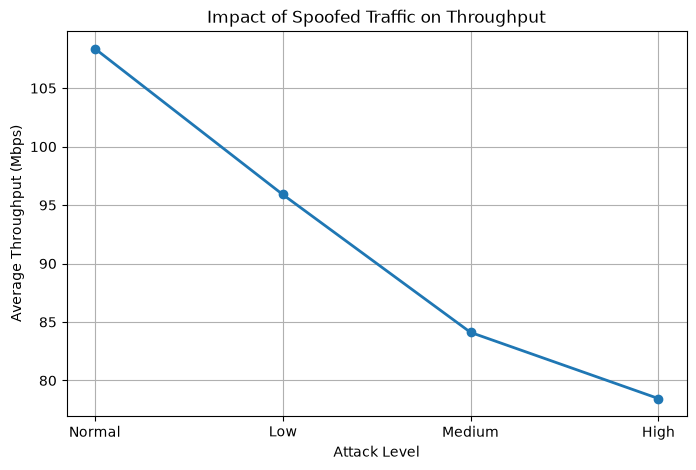

In [59]:
# Throughput vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Throughput_Mbps"],
    marker='o',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Throughput (Mbps)")

plt.title("Impact of Spoofed Traffic on Throughput")

plt.grid(True)

plt.savefig(
    "figures_step8_throughput_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

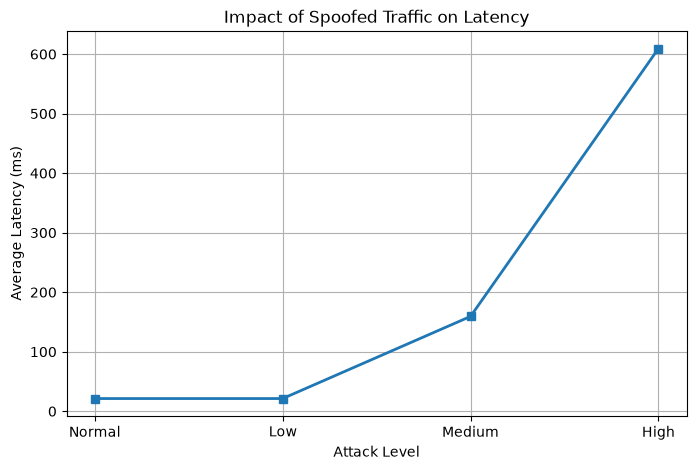

In [60]:
#Latency vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Latency_ms"],
    marker='s',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Latency (ms)")

plt.title("Impact of Spoofed Traffic on Latency")

plt.grid(True)

plt.savefig(
    "figures_step8_latency_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

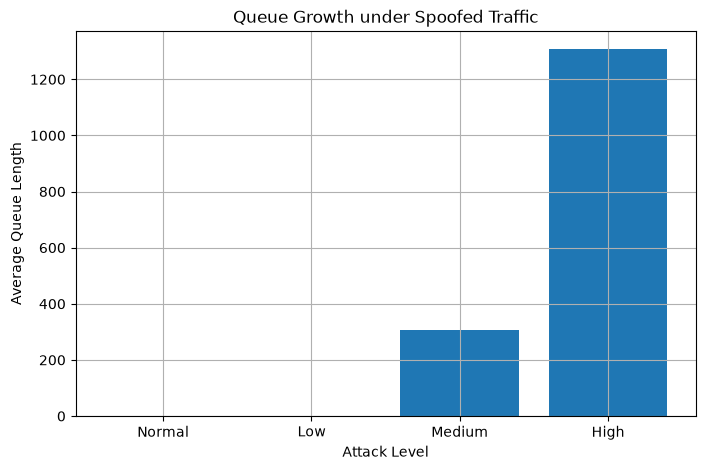

In [61]:
# Queue Length
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Queue_Packets"]
)

plt.xlabel("Attack Level")

plt.ylabel("Average Queue Length")

plt.title("Queue Growth under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_queue_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

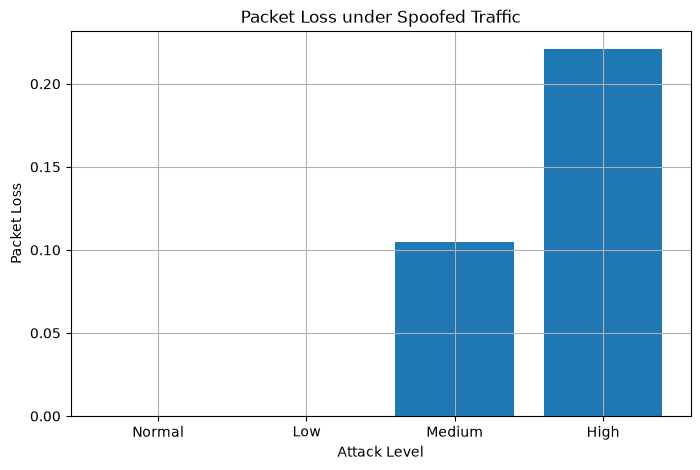

In [62]:
# Packet Loss
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Packet_Loss"]
)

plt.xlabel("Attack Level")

plt.ylabel("Packet Loss")

plt.title("Packet Loss under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_packet_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

TensorFlow: 2.20.0
Sionna: 2.0.1
Modules Imported Successfully


In [64]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0], shape=(20,), dtype=int32)


In [65]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[-1. -1.  1.  1.  1. -1. -1.  1. -1. -1. -1.  1. -1. -1.  1. -1. -1. -1.
  1. -1.], shape=(20,), dtype=float32)


In [66]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: []
Length of BER: 0
[]


In [67]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [68]:
print(ber)
len(ber)

[np.float64(0.0789), np.float64(0.0394), np.float64(0.0112), np.float64(0.0017), np.float64(0.0003), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


11

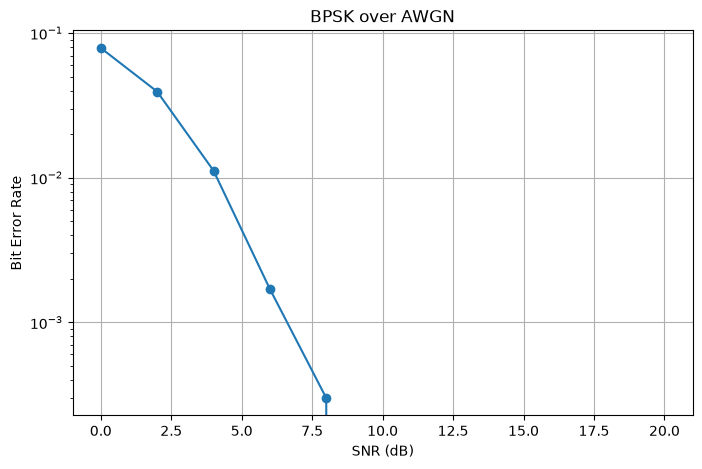

In [69]:
SNR_dB = np.arange(0,21,2)
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
import sionna

print(dir(sionna))
print("Sionna Version:", sionna.__version__)

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']
Sionna Version: 2.0.1


In [71]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [72]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']


In [73]:
import pkgutil
import sionna.phy

print("Available PHY Packages\n")

for module in pkgutil.iter_modules(sionna.phy.__path__):
    print(module.name)

Available PHY Packages

block
channel
config
constants
fec
mapping
mimo
nr
object
ofdm
signal
utils


In [74]:
import sionna.phy.channel

print(dir(sionna.phy.channel))

import sionna.phy.ofdm

print(dir(sionna.phy.ofdm))

import sionna.phy.channel as ch

print(dir(ch))

import sionna.phy.ofdm as ofdm

print(dir(ofdm))


['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [75]:
# ======================================================
# STEP 10 - Sionna PHY Integration
# Small-Scale Fading
# ======================================================

import tensorflow as tf
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

num_users = len(user_positions)

In [76]:
# Rayleigh fading coefficient

# Real part
real = tf.random.normal([num_users], dtype=tf.float32)

# Imaginary part
imag = tf.random.normal([num_users], dtype=tf.float32)

# Create complex channel coefficients
h = tf.complex(real, imag) / tf.cast(tf.sqrt(2.0), tf.complex64)

print(h[:10])

tf.Tensor(
[ 0.23155521+5.9555773e-02j -0.59582645-6.0875088e-01j
  0.22587374+2.6737338e-01j -0.9952895 -3.6743204e-03j
 -1.6886133 -3.4968692e-01j -0.7348592 +4.3686414e-01j
 -0.39408705-2.3392540e-01j  0.38163048-9.7869278e-04j
  1.2016801 -2.9962525e-01j  0.204309  -9.8090470e-01j], shape=(10,), dtype=complex64)


In [77]:
# Channel Power Gain
channel_gain = tf.abs(h)**2

channel_gain = channel_gain.numpy()

print(channel_gain[:10])

[0.0571647  0.7255867  0.12250746 0.9906148  2.9736955  0.7308684
 0.2100257  0.14564277 1.5338103  1.0039163 ]


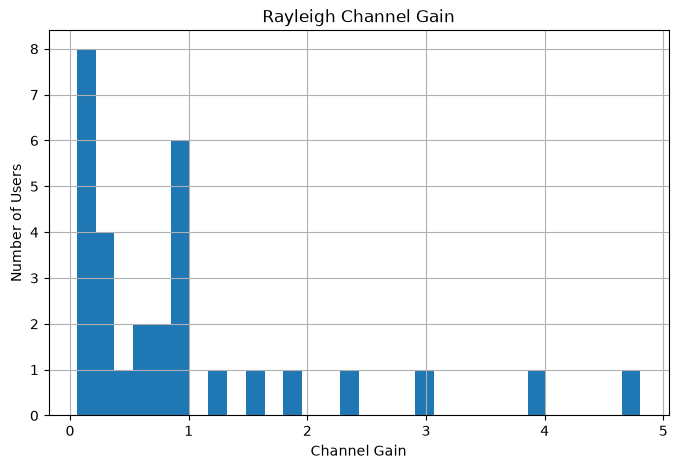

In [78]:
# Plot the Fading Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(channel_gain,
         bins=30)

plt.xlabel("Channel Gain")

plt.ylabel("Number of Users")

plt.title("Rayleigh Channel Gain")

plt.grid(True)

plt.savefig(
    "figures_step10_channel_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
received_power
channel_gain = channel_gain.reshape(-1, 1)

received_power_fading = received_power + 10*np.log10(channel_gain)

print(received_power_fading[:10])

[[-79.54964    -79.91559392 -62.68601879]
 [-64.43052752 -70.98577154 -66.49936065]
 [-60.75023518 -75.06103575 -77.47181335]
 [-62.50984555 -61.04498028 -68.72417093]
 [-56.36819409 -65.16760621 -62.52463584]
 [-72.02754045 -72.67272421 -62.10321276]
 [-59.90430256 -74.47868053 -73.7660318 ]
 [-75.59247821 -75.90644798 -57.87065516]
 [-67.57475857 -54.35298587 -67.62464709]
 [-61.60840092 -69.21035905 -71.53994552]]


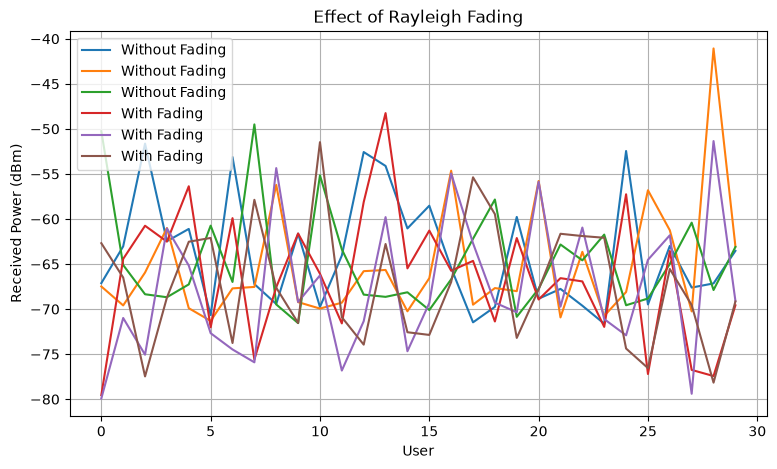

In [80]:
# Plot the Difference
plt.figure(figsize=(9,5))

plt.plot(received_power,
         label="Without Fading")

plt.plot(received_power_fading,
         label="With Fading")

plt.xlabel("User")

plt.ylabel("Received Power (dBm)")

plt.title("Effect of Rayleigh Fading")

plt.legend()

plt.grid(True)

plt.savefig(
    "figures_step10_received_power_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
# Recalculate SINR
received_power_mW = 10**(received_power_fading/10)

noise_power = 1e-10

sinr = received_power_mW / noise_power

sinr_dB = 10*np.log10(sinr)

print(sinr_dB[:10])

[[20.45036    20.08440608 37.31398121]
 [35.56947248 29.01422846 33.50063935]
 [39.24976482 24.93896425 22.52818665]
 [37.49015445 38.95501972 31.27582907]
 [43.63180591 34.83239379 37.47536416]
 [27.97245955 27.32727579 37.89678724]
 [40.09569744 25.52131947 26.2339682 ]
 [24.40752179 24.09355202 42.12934484]
 [32.42524143 45.64701413 32.37535291]
 [38.39159908 30.78964095 28.46005448]]


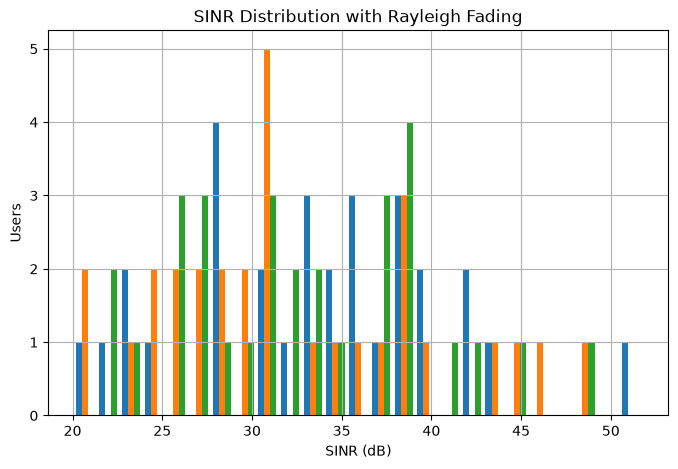

In [82]:
# Compare SINR
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=25)

plt.xlabel("SINR (dB)")

plt.ylabel("Users")

plt.title("SINR Distribution with Rayleigh Fading")

plt.grid(True)

plt.savefig(
    "figures_step10_sinr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
# =====================================================
# STEP 11 - Beamforming
# =====================================================

beamforming_gain_dB = 6

print("Beamforming Gain:", beamforming_gain_dB, "dB")

received_power_beamforming = received_power_fading + beamforming_gain_dB

print(received_power_beamforming[:5])
print(received_power_fading.shape)

Beamforming Gain: 6 dB
[[-73.54964    -73.91559392 -56.68601879]
 [-58.43052752 -64.98577154 -60.49936065]
 [-54.75023518 -69.06103575 -71.47181335]
 [-56.50984555 -55.04498028 -62.72417093]
 [-50.36819409 -59.16760621 -56.52463584]]
(30, 3)


In [84]:
# Calculate New SINR
received_power_mW = 10 ** (received_power_beamforming / 10)
# Assume:
noise_power_mW = 1e-10

sinr_beam = received_power_mW / noise_power_mW

sinr_beam_dB = 10 * np.log10(sinr_beam)

In [85]:
# Compare Average SINR
print("Average SINR without Beamforming:")

print(np.mean(sinr_dB))

print()

print("Average SINR with Beamforming:")

print(np.mean(sinr_beam_dB))

Average SINR without Beamforming:
32.89621560375239

Average SINR with Beamforming:
38.89621560375239


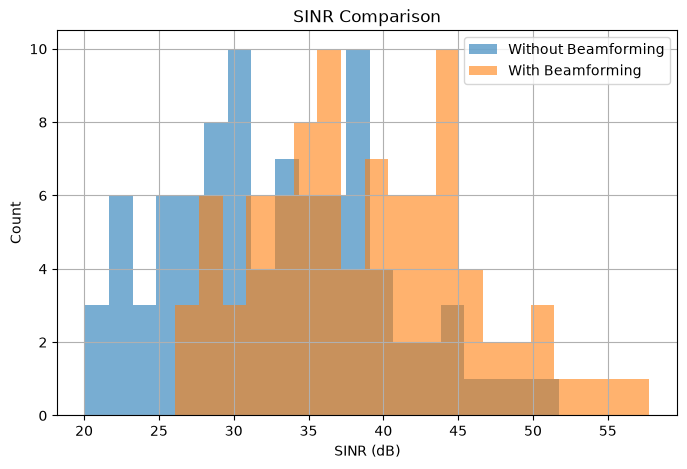

In [86]:
# Plot the Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    sinr_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="Without Beamforming"
)

plt.hist(
    sinr_beam_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="With Beamforming"
)

plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.title("SINR Comparison")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_sinr_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [88]:
import numpy as np

# Check the shape first
print("Received power shape:", received_power_beamforming.shape)

# Assign each user to the BS with the highest received power
assignments_beamforming = np.argmax(
    received_power_beamforming,
    axis=1
)

print("User assignments:")
print(assignments_beamforming)

Received power shape: (30, 3)
User assignments:
[2 0 0 1 0 2 0 2 1 0 2 2 0 0 0 0 1 2 2 0 1 2 1 2 0 1 1 2 1 1]


In [89]:
# Count Users Per Base Station
num_bs = received_power_beamforming.shape[1]

users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

BS 1: 11 users
BS 2: 9 users
BS 3: 10 users


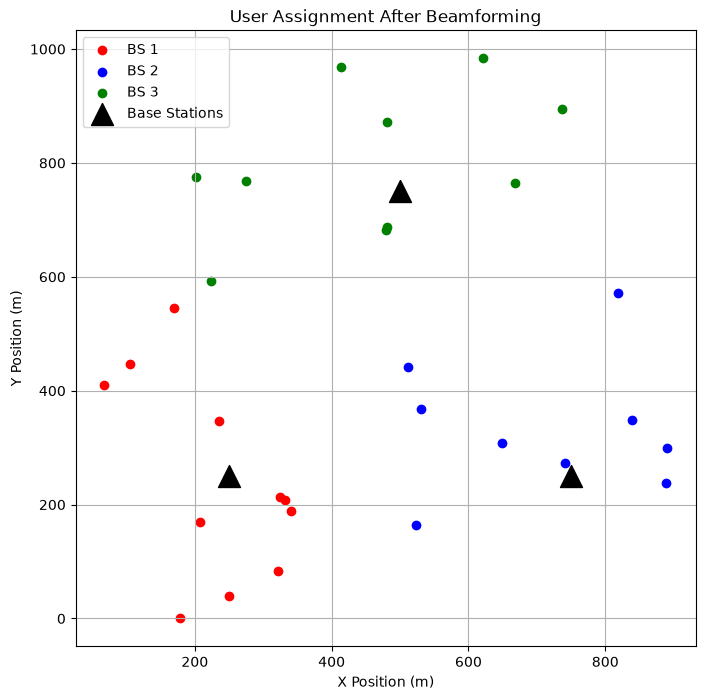

In [90]:
# Visualize User Assignment
colors = ["red", "blue", "green"]

plt.figure(figsize=(8,8))

for bs in range(num_bs):

    users = user_positions[
        assignments_beamforming == bs
    ]

    plt.scatter(
        users[:,0],
        users[:,1],
        color=colors[bs],
        label=f"BS {bs+1}"
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker="^",
    s=250,
    color="black",
    label="Base Stations"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("User Assignment After Beamforming")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_user_assignment_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()